In [6]:
!pip install scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 4.2 MB/s  0:00:08m0:00:0100:01


# Part 1: Foundational Exercises on 20 Newsgroups Dataset


## 1. Library Imports and Environment Setup


In [7]:
import os, sys, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configure plot style
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11
pd.set_option("display.max_columns", 15)
pd.set_option("display.max_colwidth", 100)

print("All libraries imported successfully.")
print(f"Python : {sys.version.split()[0]}")
print(f"NumPy   : {np.__version__}")
print(f"Pandas : {pd.__version__}")
print(f"Seaborn : {sns.__version__}")

All libraries imported successfully.
Python : 3.14.7
NumPy   : 2.5.2
Pandas : 3.0.5
Seaborn : 0.13.2


## 2. Loading 20 Newsgroups Dataset


In [ ]:
def load_20newsgroups(dataset_dir="20_newsgroups"):
    records = []
    dataset_path = Path(dataset_dir)

    if not dataset_path.exists():
        raise FileNotFoundError(f"Directory '{dataset_dir}' not found!")



    start = time.time()

    for category_dir in sorted(dataset_path.iterdir()):
        if not category_dir.is_dir():
            continue

        category = category_dir.name
        super_cat = category.split(".")[0]    # e.g. 'comp'

        for fpath in category_dir.iterdir():
            if not fpath.is_file():
                continue

            # Use latin-1 encoding for old Usenet posts
            with open(fpath, "r", encoding="latin-1") as f:
                text = f.read()

            words = text.split()
            records.append({
                "category":        category,
                "super_category": super_cat,
                "file_id":         fpath.name,
                "text":            text,
                "char_count":      len(text),
                "word_count":      len(words),
                "line_count":      len(text.splitlines()),
                "avg_word_length": (
                    round(len(text) / len(words), 2) if words else 0.0
                ),
            })

    df = pd.DataFrame(records)
    elapsed = time.time() - start
    print(f"Loaded {len(df):,} documents across "
          f"{df['category'].nunique()} categories in {elapsed:.2f}s")
    return df


# Load
df = load_20newsgroups("20_newsgroups")

Loaded 19,997 documents across 20 categories in 2.77s


## 3. Dataset Size, Dimensions, and Feature Overview


In [10]:
print("=" * 60)
print(f"Shape : {df.shape}     ->    {df.shape[0]:,} rows   *   {df.shape[1]} cols")
print("=" * 60)

print("\n-- DataFrame Info --")
df.info(memory_usage="deep")

print("\n-- Column Data Types --")
print(df.dtypes)

print("\n-- First 5 Records --")
df.head()

Shape : (19997, 8)     ->    19,997 rows   *   8 cols

-- DataFrame Info --
<class 'pandas.DataFrame'>
RangeIndex: 19997 entries, 0 to 19996
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   category         19997 non-null  str    
 1   super_category   19997 non-null  str    
 2   file_id          19997 non-null  str    
 3   text             19997 non-null  str    
 4   char_count       19997 non-null  int64  
 5   word_count       19997 non-null  int64  
 6   line_count       19997 non-null  int64  
 7   avg_word_length  19997 non-null  float64
dtypes: float64(1), int64(3), str(4)
memory usage: 48.8 MB

-- Column Data Types --
category               str
super_category         str
file_id                str
text                   str
char_count           int64
word_count           int64
line_count           int64
avg_word_length    float64
dtype: object

-- First 5 Records --


,category,super_category,file_id,text,char_count,word_count,line_count,avg_word_length
0,alt.atheism,alt,53366,Path: cantaloupe.srv.cs.cmu.edu!das-news.harvard.edu!noc.near.net!howland.reston.ans.net!usenet....,1926,220,48,8.75
1,alt.atheism,alt,53367,Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:53367 talk.religion.misc:83778 talk.origins:40952\nN...,2456,243,50,10.11
2,alt.atheism,alt,51247,Newsgroups: alt.atheism\nPath: cantaloupe.srv.cs.cmu.edu!crabapple.srv.cs.cmu.edu!fs7.ece.cmu.ed...,2144,309,44,6.94
3,alt.atheism,alt,51248,Xref: cantaloupe.srv.cs.cmu.edu talk.religion.misc:82803 alt.atheism:51248\nPath: cantaloupe.srv...,929,98,23,9.48
4,alt.atheism,alt,51249,Path: cantaloupe.srv.cs.cmu.edu!crabapple.srv.cs.cmu.edu!fs7.ece.cmu.edu!europa.eng.gtefsd.com!h...,1976,295,43,6.70


## 4. Document Distribution Across Categories


In [11]:
cat_counts = df["category"].value_counts().reset_index()
cat_counts.columns = ["Category", "Documents"]
cat_counts["Percent (%)"] = (
    (cat_counts["Documents"] / len(df) * 100).round(2)
)

print("-- Document Distribution Across 20 Categories --")
display(cat_counts)

print(f"\nMin per category : {cat_counts['Documents'].min()}")


print(f"Max per category : {cat_counts['Documents'].max()}")
print(f"Mean per category: {cat_counts['Documents'].mean():.1f}")

-- Document Distribution Across 20 Categories --


,Category,Documents,Percent (%)
0,alt.atheism,1000,5.00
1,comp.graphics,1000,5.00
2,comp.os.ms-windows.misc,1000,5.00
3,comp.sys.ibm.pc.hardware,1000,5.00
4,comp.sys.mac.hardware,1000,5.00
5,comp.windows.x,1000,5.00
6,misc.forsale,1000,5.00
7,rec.autos,1000,5.00
8,rec.motorcycles,1000,5.00
9,rec.sport.baseball,1000,5.00



Min per category : 997
Max per category : 1000
Mean per category: 999.9


## 5. Sample Documents from Different Categories


In [12]:
for idx, cat in enumerate(["sci.space", "rec.sport.hockey"], 1):
    doc = df[df["category"] == cat].iloc[0]
    print("=" * 70)
    print(f"SAMPLE {idx}: category = '{doc['category']}' | "
          f"file = '{doc['file_id']}'")
    print(f"           words = {doc['word_count']} | "
          f"chars = {doc['char_count']} | lines = {doc['line_count']}")
    print("-" * 70)
    # Show first 600 chars to keep output readable
    preview = doc["text"][:600]
    if len(doc["text"]) > 600:
        preview += "\n... [truncated] ..."
    print(preview)
    print("=" * 70, "\n")

SAMPLE 1: category = 'sci.space' | file = '60186'
           words = 123 | chars = 1549 | lines = 32
----------------------------------------------------------------------
Xref: cantaloupe.srv.cs.cmu.edu rec.nude:15829 rec.radio.amateur.misc:36913 rec.radio.cb:2650 rec.radio.shortwave:23053 sci.aeronautics:5975 sci.astro:34146 sci.econ:16233 sci.med:58068 sci.misc:8089 sci.space:60186 soc.bi:22986
Newsgroups: rec.ham-radio,rec.nude,rec.radio.amateur.misc,rec.radio.cb,rec.radio.shortwave,sci.aeronautic,sci.aeronautics,sci.astro,sci.econ,sci.med,sci.misc,sci.space,soc.bi
Path: cantaloupe.srv.cs.cmu.edu!crabapple.srv.cs.cmu.edu!fs7.ece.cmu.edu!europa.eng.gtefsd.com!howland.reston.ans.net!noc.near.net!uunet!mcsun!news.funet.fi!ousrvr.oulu.fi!vttoulu.tko.vtt.fi!dfo
F
... [truncated] ...

SAMPLE 2: category = 'rec.sport.hockey' | file = '54069'
           words = 595 | chars = 4751 | lines = 142
----------------------------------------------------------------------
Newsgroups: rec.sport.hock

## 6. Data Types and Feature Nature Identification


In [13]:
dtype_df = pd.DataFrame({
    "Feature":    df.columns,
    "Pandas dtype": [str(d) for d in df.dtypes],
    "Nature": [
        "Categorical (Nominal)" if c in ("category", "super_category") else
        "Identifier"             if c == "file_id" else
        "Unstructured Text"      if c == "text" else
        "Numerical (Discrete)" if c in ("char_count", "word_count", "line_count") else
        "Numerical (Continuous)"
        for c in df.columns
    ],
    "Nulls": df.isnull().sum().values,
})
display(dtype_df)

,Feature,Pandas dtype,Nature,Nulls
0,category,str,Categorical (Nominal),0
1,super_category,str,Categorical (Nominal),0
2,file_id,str,Identifier,0
3,text,str,Unstructured Text,0
4,char_count,int64,Numerical (Discrete),0
5,word_count,int64,Numerical (Discrete),0
6,line_count,int64,Numerical (Discrete),0
7,avg_word_length,float64,Numerical (Continuous),0


## 7. Histograms of Numerical and Categorical Features


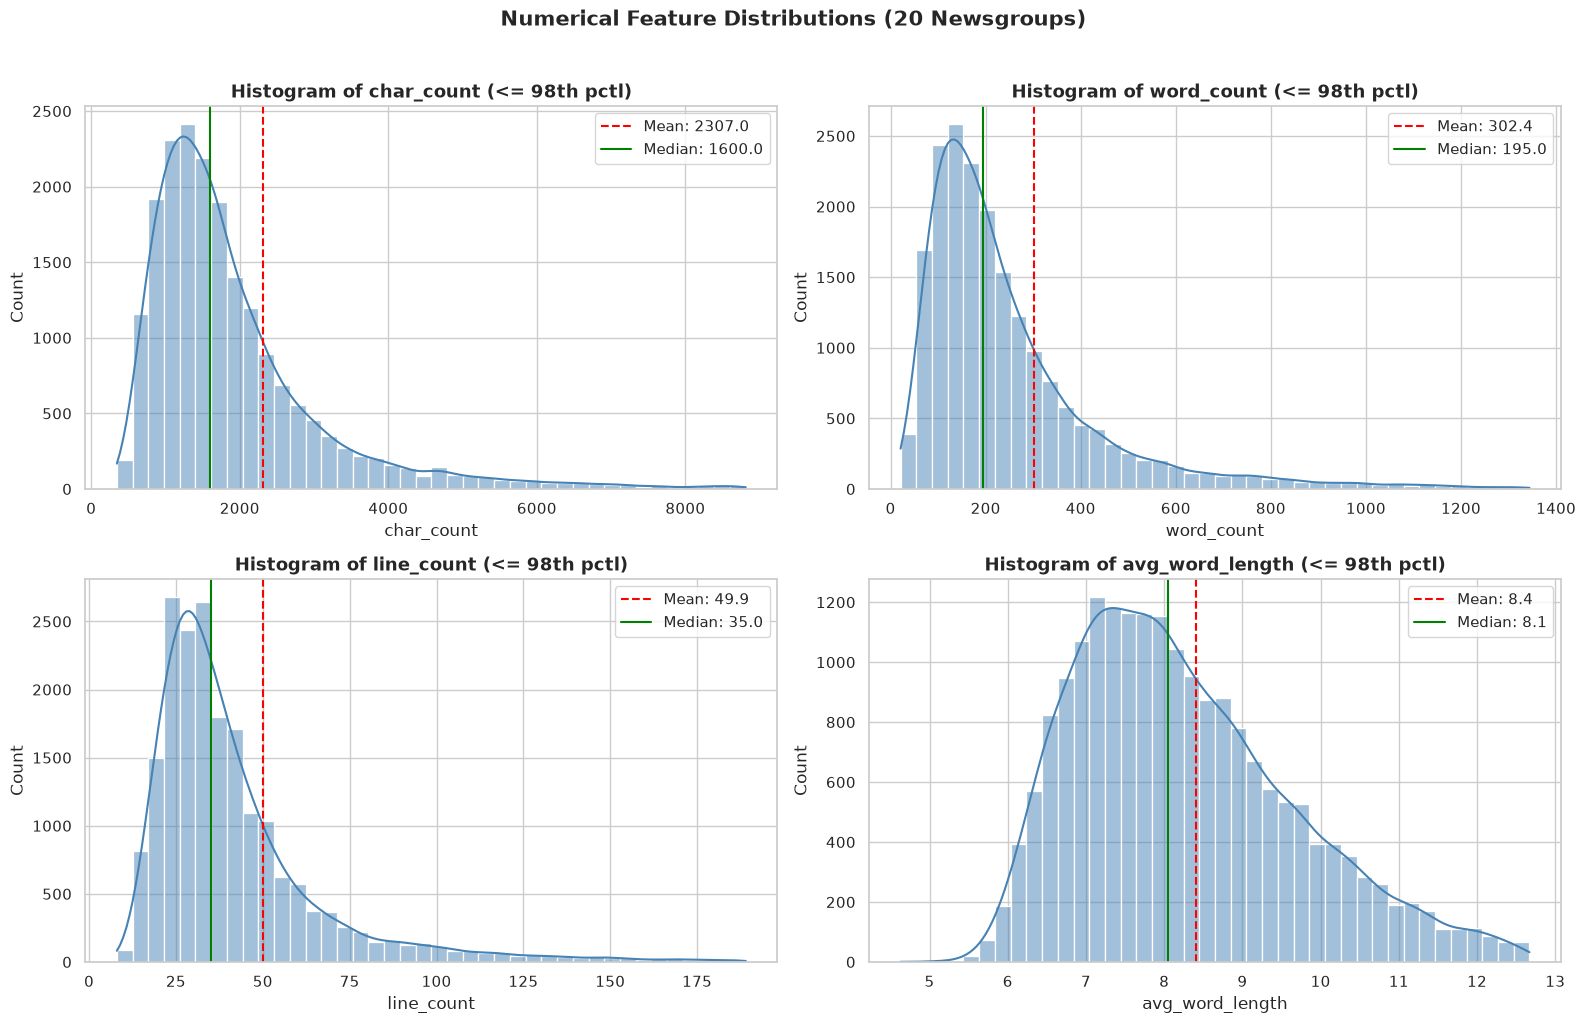

/tmp/ipykernel_5140/775062217.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="super_category",
/tmp/ipykernel_5140/775062217.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y="category",


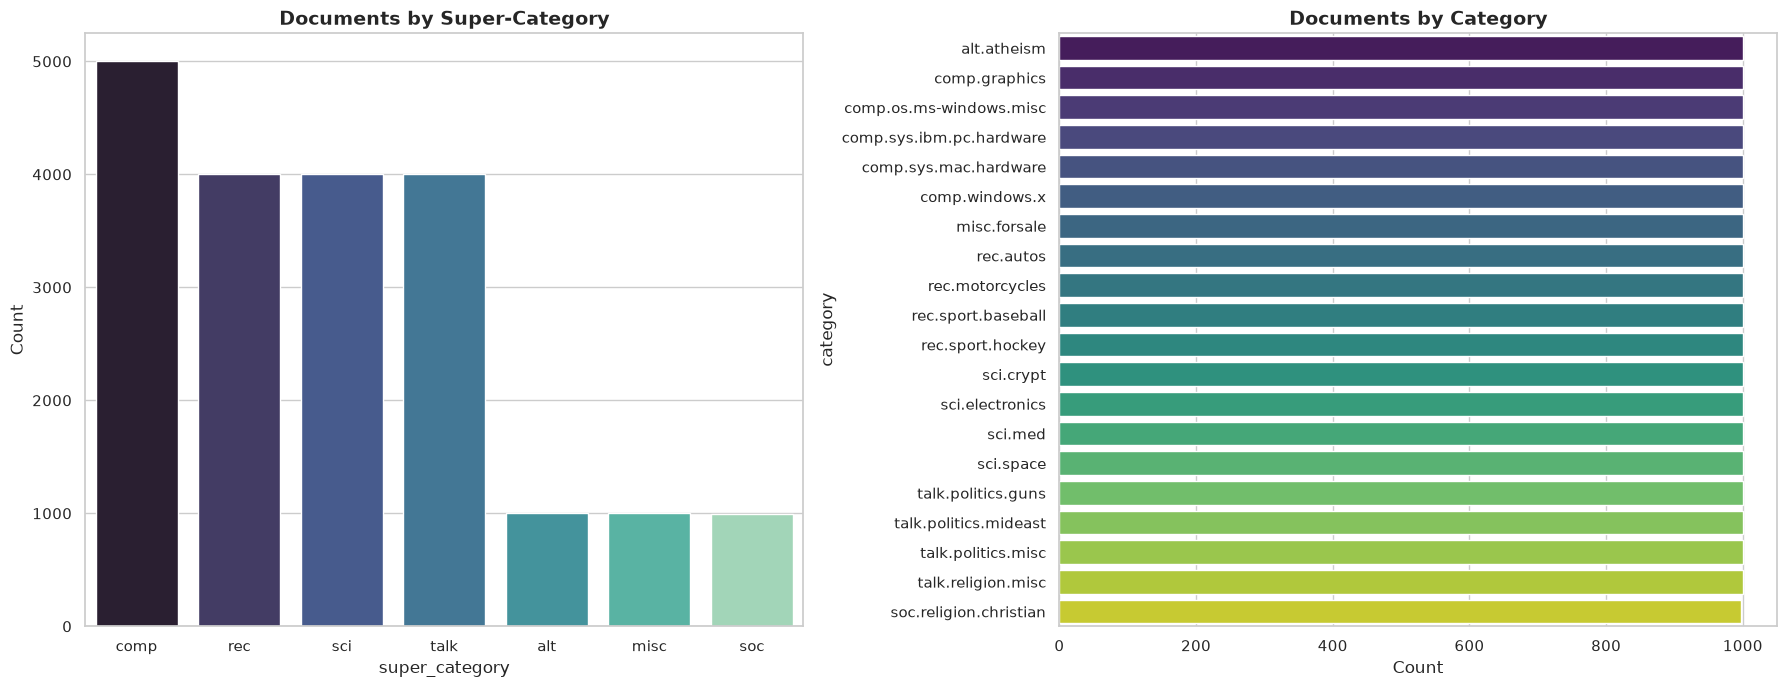

In [14]:
num_cols = ["char_count", "word_count", "line_count", "avg_word_length"]

# Numerical feature histograms (2x2 grid)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, col in zip(axes.flat, num_cols):
    p98 = df[col].quantile(0.98)
    subset = df[df[col] <= p98][col]
    sns.histplot(subset, kde=True, bins=40, color="steelblue", ax=ax)
    ax.set_title(f"Histogram of {col} (<= 98th pctl)",
                 fontsize=13, fontweight="bold")
    ax.set_ylabel("Count")

    mean_v = df[col].mean()
    med_v = df[col].median()
    ax.axvline(mean_v, color="red",    ls="--", lw=1.5,
                label=f"Mean: {mean_v:.1f}")
    ax.axvline(med_v, color="green", ls="-", lw=1.5,
                label=f"Median: {med_v:.1f}")
    ax.legend()

plt.suptitle("Numerical Feature Distributions (20 Newsgroups)",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Categorical distributions (super-category + category)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

sns.countplot(data=df, x="super_category",
              order=df["super_category"].value_counts().index,
              palette="mako", ax=ax1)
ax1.set_title("Documents by Super-Category", fontsize=14, fontweight="bold")
ax1.set_ylabel("Count")

sns.countplot(data=df, y="category",
              order=df["category"].value_counts().index,
              palette="viridis", ax=ax2)
ax2.set_title("Documents by Category", fontsize=14, fontweight="bold")
ax2.set_xlabel("Count")

plt.tight_layout()
plt.show()

## 8. Descriptive Statistics of All Feature Types


In [15]:
# Numerical statistics
num_stats = df[num_cols].describe(percentiles=[.25, .5, .75]).T
num_stats["variance"] = df[num_cols].var()
num_stats["iqr"]       = num_stats["75%"] - num_stats["25%"]
num_stats["skewness"] = df[num_cols].skew()

num_cols_order = [
    "count","mean","std","variance","min","25%","50%","75%","max","iqr","skewness"


]
num_stats = num_stats[num_cols_order]
num_stats.columns = [
    "Count","Mean","Std","Variance","Min","Q1","Median","Q3","Max","IQR","Skewness"
]

print("-- Numerical Features --")
display(num_stats.round(2))

# Categorical statistics
print("\n-- Categorical Features --")
display(df[["category", "super_category"]].describe().T)

-- Numerical Features --


,Count,Mean,Std,Variance,Min,Q1,Median,Q3,Max,IQR,Skewness
char_count,19997.0,2306.99,3912.98,15311415.52,345.00,1139.00,1600.00,2321.0,161040.00,1182.00,12.70
word_count,19997.0,302.38,510.96,261079.88,21.00,126.00,195.00,314.0,11839.00,188.00,10.51
line_count,19997.0,49.95,80.09,6414.50,8.00,26.00,35.00,50.0,2614.00,24.00,11.89
avg_word_length,19997.0,8.41,2.17,4.73,4.63,7.19,8.05,9.2,59.66,2.01,10.28



-- Categorical Features --


,count,unique,top,freq
category,19997,20,alt.atheism,1000
super_category,19997,7,comp,5000


## 9. Visual and Statistical Analysis – Box Plots


/tmp/ipykernel_5140/3938545411.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df["word_count"] <= p95],


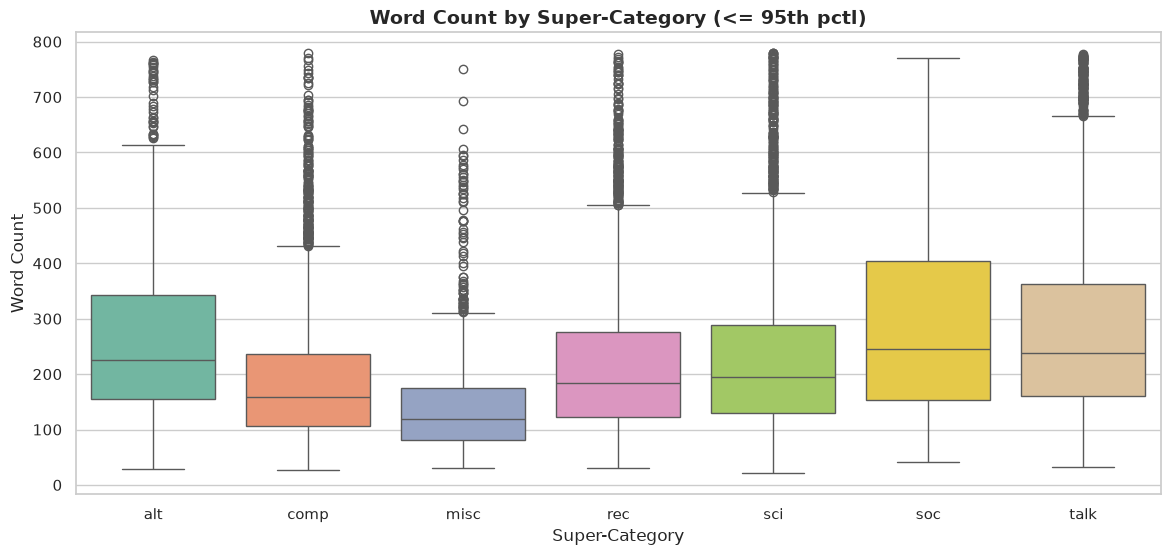

/tmp/ipykernel_5140/3938545411.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, y="category", x="log_char", palette="tab20", orient="h")


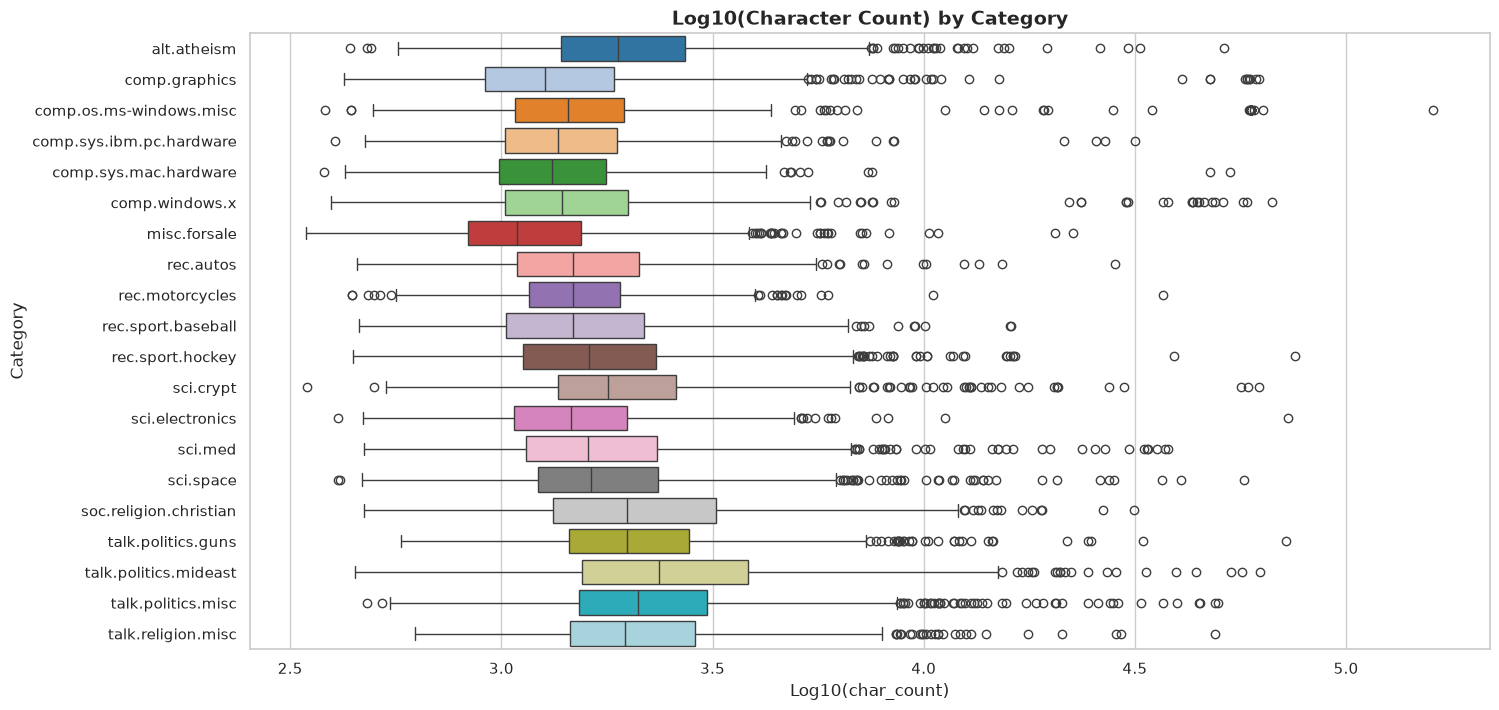

In [16]:
# Box 1: word_count by super-category
p95 = df["word_count"].quantile(0.95)

plt.figure(figsize=(14, 6))
sns.boxplot(data=df[df["word_count"] <= p95],
             x="super_category", y="word_count", palette="Set2")
plt.title("Word Count by Super-Category (<= 95th pctl)",
           fontsize=14, fontweight="bold")
plt.xlabel("Super-Category")
plt.ylabel("Word Count")
plt.show()

# Box 2: log10(char_count) by category
df_plot = df.copy()
df_plot["log_char"] = np.log10(df_plot["char_count"].replace(0, 1))

plt.figure(figsize=(16, 8))
sns.boxplot(data=df_plot, y="category", x="log_char", palette="tab20", orient="h")
plt.title("Log10(Character Count) by Category", fontsize=14, fontweight="bold")
plt.xlabel("Log10(char_count)")


plt.ylabel("Category")
plt.show()

## 10. Joint Plots and Correlation Analysis


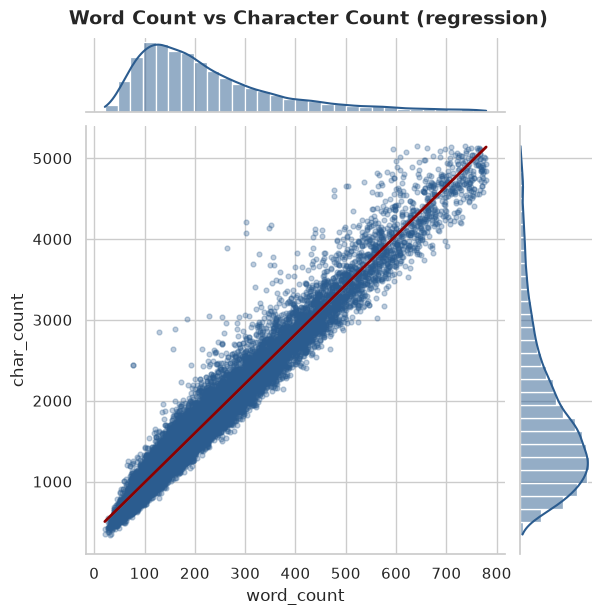

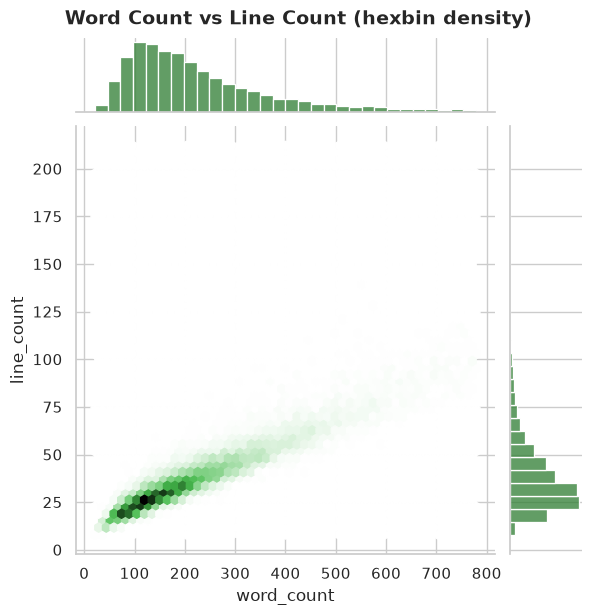

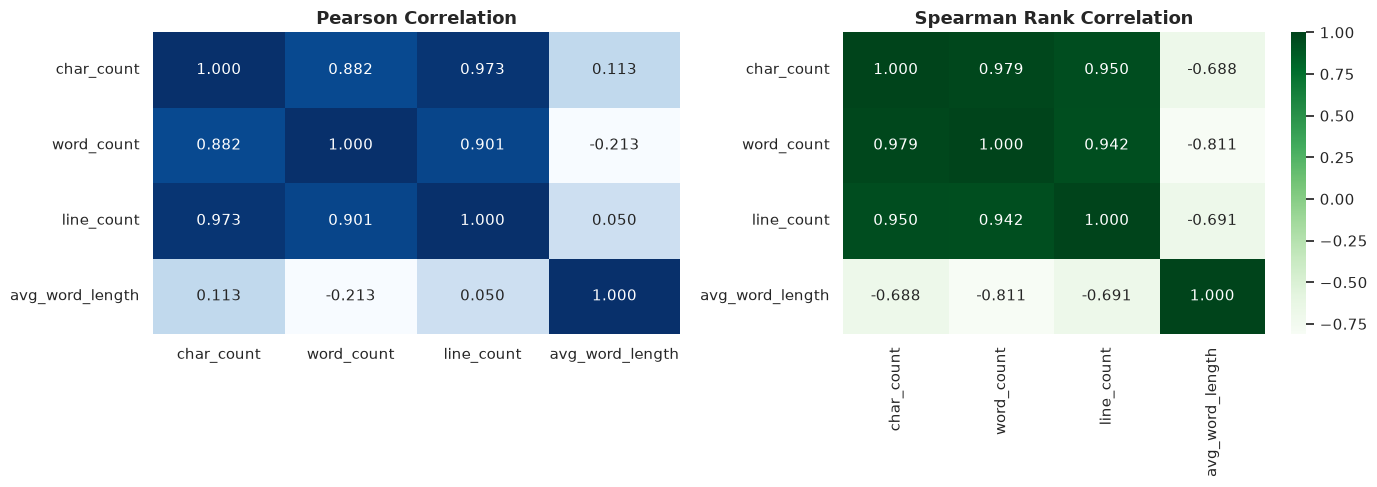

In [17]:
# Filter to 95th percentile for clean scatter
mask = (
    (df["char_count"] <= df["char_count"].quantile(0.95)) &
    (df["word_count"] <= df["word_count"].quantile(0.95))
)
df_f = df[mask].copy()

# Joint 1: word_count vs char_count (regression)
g1 = sns.jointplot(data=df_f, x="word_count", y="char_count", kind="reg",
                   color="#2b5c8f",
                   marginal_kws=dict(bins=30, fill=True),
                   joint_kws=dict(scatter_kws={"alpha": 0.3, "s": 12},
                                  line_kws={"color": "darkred", "lw": 2}))
g1.fig.suptitle("Word Count vs Character Count (regression)", y=1.02,
                fontsize=14, fontweight="bold")
plt.show()

# Joint 2: word_count vs line_count (hexbin)
g2 = sns.jointplot(data=df_f, x="word_count", y="line_count", kind="hex",
                   color="#2e7d32", marginal_kws=dict(bins=30, fill=True))
g2.fig.suptitle("Word Count vs Line Count (hexbin density)", y=1.02,
                fontsize=14, fontweight="bold")
plt.show()

# Correlation matrices
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(df[num_cols].corr("pearson"), annot=True, fmt=".3f",
            cmap="Blues", ax=ax1, cbar=False)
ax1.set_title("Pearson Correlation", fontsize=13, fontweight="bold")

sns.heatmap(df[num_cols].corr("spearman"), annot=True, fmt=".3f",
            cmap="Greens", ax=ax2)
ax2.set_title("Spearman Rank Correlation", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()

## 11. Key Insights and Analysis (Part 1)


# Part 2: California Housing Dataset Analysis and Data Processing


## 1. Library Imports and Environment Setup (Part 2)


In [20]:
!pip install scikit-learn

  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 436.3 kB/s  0:00:20 eta 0:00:01
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [scikit-learn] [scikit-learn]


In [21]:
import os, sys, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.datasets import fetch_california_housing
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

# Configure plot aesthetic
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11
pd.set_option("display.max_columns", 15)
pd.set_option("display.width", 1000)

print("All libraries imported successfully.")
print(f"Python      : {sys.version.split()[0]}")
print(f"NumPy       : {np.__version__}")
print(f"Pandas      : {pd.__version__}")
print(f"Seaborn     : {sns.__version__}")
print(f"Scikit-Learn: {sys.modules['sklearn'].__version__}")

All libraries imported successfully.
Python      : 3.14.7
NumPy       : 2.5.2
Pandas      : 3.0.5
Seaborn     : 0.13.2
Scikit-Learn: 1.9.1


## 2. Loading California Housing Dataset


In [22]:
# Load California Housing dataset into DataFrame
housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()

print("=" * 60)
print(f"Shape : {df.shape}     ->      {df.shape[0]:,} rows   *   {df.shape[1]} cols")
print("=" * 60)

print("\n-- DataFrame Info --")
df.info(memory_usage="deep")

print("\n-- Column Data Types --")
print(df.dtypes)



print("\n-- First 5 Records --")
df.head()

Shape : (20640, 9)     ->      20,640 rows   *   9 cols

-- DataFrame Info --
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB

-- Column Data Types --
MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object

-- First 5 Records --


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 3. Comprehensive Statistical Analysis of Features


In [23]:
def compute_statistical_summary(data: pd.DataFrame) -> pd.DataFrame:
    stats_dict = []
    for col in data.columns:
        s = data[col].dropna()


        mode_val = s.mode().iloc[0] if not s.mode().empty else np.nan

        stats_dict.append({
            "Feature": col,
            "Mean": s.mean(),
            "Median": s.median(),
            "Mode": mode_val,
            "Std Dev": s.std(),
            "Variance": s.var(),
            "Min": s.min(),
            "Max": s.max(),
            "Range": s.max() - s.min(),
            "IQR": s.quantile(0.75) - s.quantile(0.25),
            "Skewness": s.skew(),
            "Kurtosis": s.kurtosis()
        })
    return pd.DataFrame(stats_dict).set_index("Feature")

summary_df = compute_statistical_summary(df)
print("-- Comprehensive Statistical Summary of Features --")
display(summary_df.round(4))

-- Comprehensive Statistical Summary of Features --


,Mean,Median,Mode,Std Dev,Variance,Min,Max,Range,IQR,Skewness,Kurtosis
Feature,,,,,,,,,,,
MedInc,3.8707,3.5348,3.125,1.8998,3.609300e+00,0.4999,15.0001,14.5002,2.1798,1.6467,4.9525
HouseAge,28.6395,29.0000,52.000,12.5856,1.583963e+02,1.0000,52.0000,51.0000,19.0000,0.0603,-0.8006
AveRooms,5.4290,5.2291,5.000,2.4742,6.121500e+00,0.8462,141.9091,141.0629,1.6117,20.6979,879.3533
AveBedrms,1.0967,1.0488,1.000,0.4739,2.246000e-01,0.3333,34.0667,33.7333,0.0934,31.3170,1636.7120
Population,1425.4767,1166.0000,891.000,1132.4621,1.282470e+06,3.0000,35682.0000,35679.0000,938.0000,4.9359,73.5531
AveOccup,3.0707,2.8181,3.000,10.3860,1.078700e+02,0.6923,1243.3333,1242.6410,0.8525,97.6396,10651.0106
Latitude,35.6319,34.2600,34.060,2.1360,4.562300e+00,32.5400,41.9500,9.4100,3.7800,0.4660,-1.1178
Longitude,-119.5697,-118.4900,-118.310,2.0035,4.014100e+00,-124.3500,-114.3100,10.0400,3.7900,-0.2978,-1.3302
MedHouseVal,2.0686,1.7970,5.000,1.1540,1.331600e+00,0.1500,5.0000,4.8500,1.4512,0.9778,0.3279


## 4. Correlation Matrix and Feature Pair Relationships


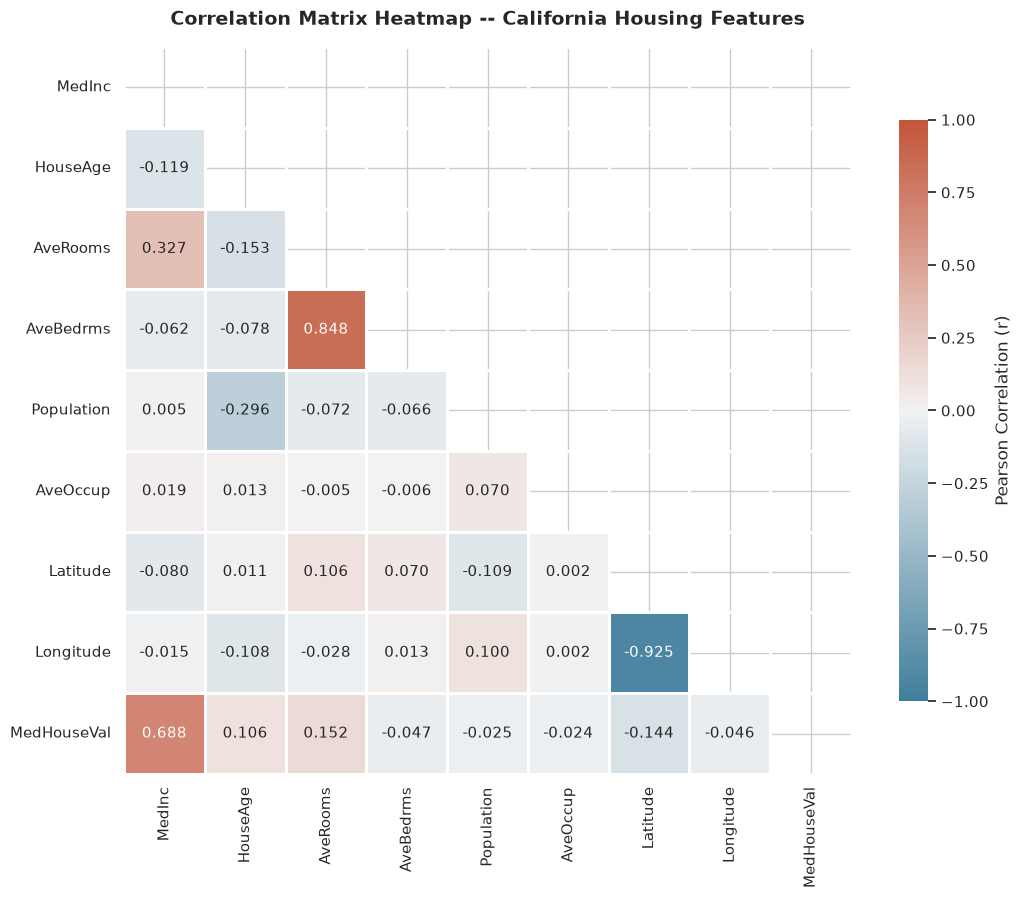

STRONGLY CORRELATED VARIABLE PAIRS (|r| >= 0.5):
 * Latitude       <-> Longitude      : r = -0.9247 (Very Strong Negative)
 * AveRooms       <-> AveBedrms      : r = +0.8476 (Very Strong Positive)
 * MedInc         <-> MedHouseVal    : r = +0.6881 (Strong Positive)


In [24]:
corr_matrix = df.corr()

# Correlation Heatmap
plt.figure(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap=cmap,
    vmax=1.0,
    vmin=-1.0,
    center=0,
    annot=True,
    fmt=".3f",
    square=True,
    linewidths=1.0,
    cbar_kws={"shrink": 0.8, "label": "Pearson Correlation (r)"}
)
plt.title("Correlation Matrix Heatmap -- California Housing Features",
           fontsize=14, pad=16, weight="bold")
plt.tight_layout()
plt.show()

# Identify strongly correlated pairs (|r| >= 0.5)
print("=" * 70)
print("STRONGLY CORRELATED VARIABLE PAIRS (|r| >= 0.5):")
print("=" * 70)
strong_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        col1 = corr_matrix.columns[i]
        col2 = corr_matrix.columns[j]
        r_val = corr_matrix.iloc[i, j]
        if abs(r_val) >= 0.5:
            strong_pairs.append((col1, col2, r_val))

for col1, col2, r in sorted(strong_pairs, key=lambda x: abs(x[2]), reverse=True):
    direction = "Positive" if r > 0 else "Negative"
    strength = "Very Strong" if abs(r) >= 0.8 else "Strong"
    print(f" * {col1:<14} <-> {col2:<14} : r = {r:+.4f} ({strength} {direction})")

## 5. Visualization Suite (Histograms, Box Plots, Scatter Plots, Bar Chart)


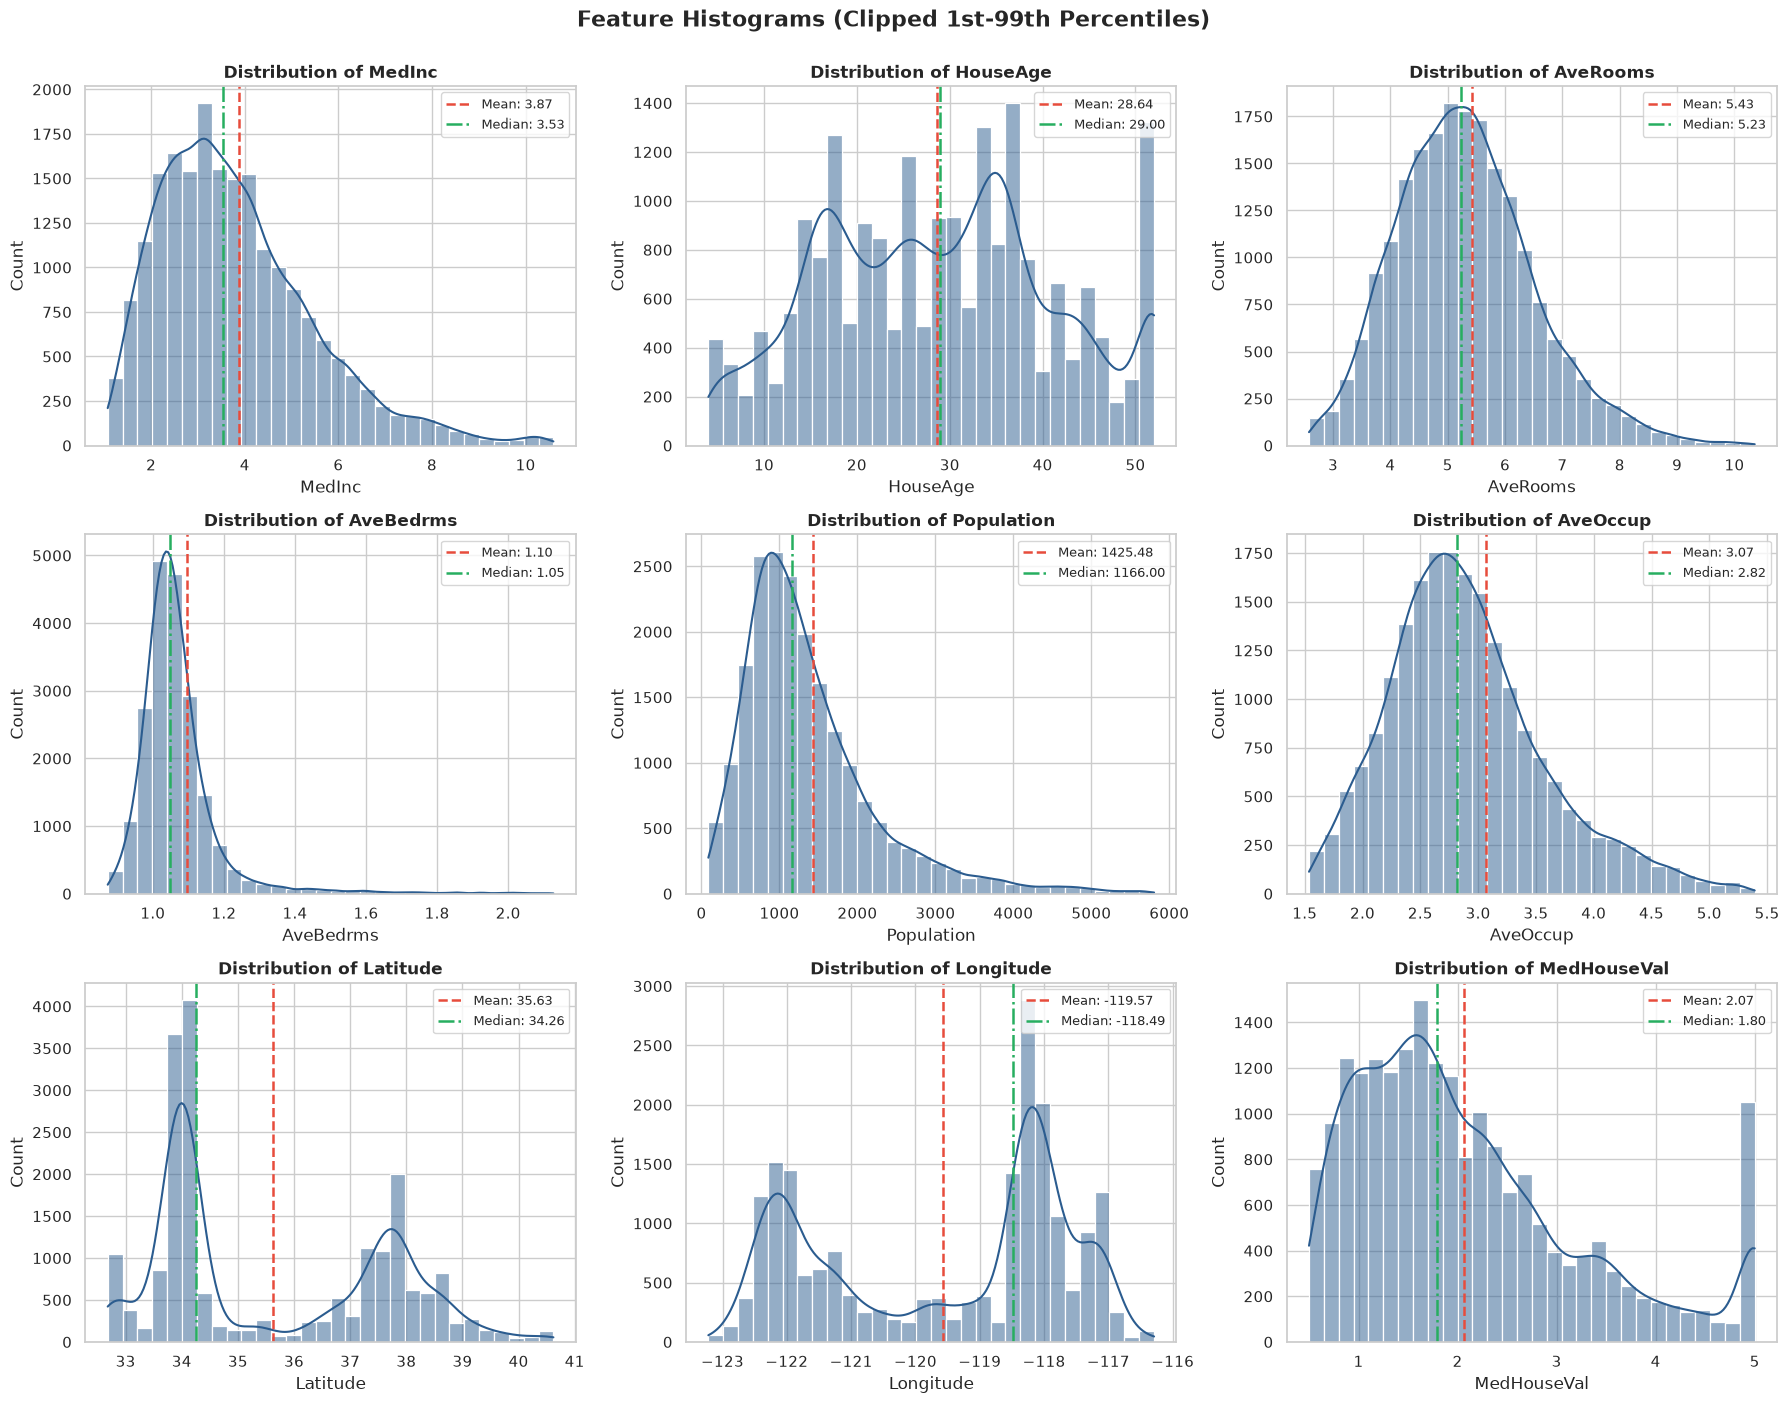

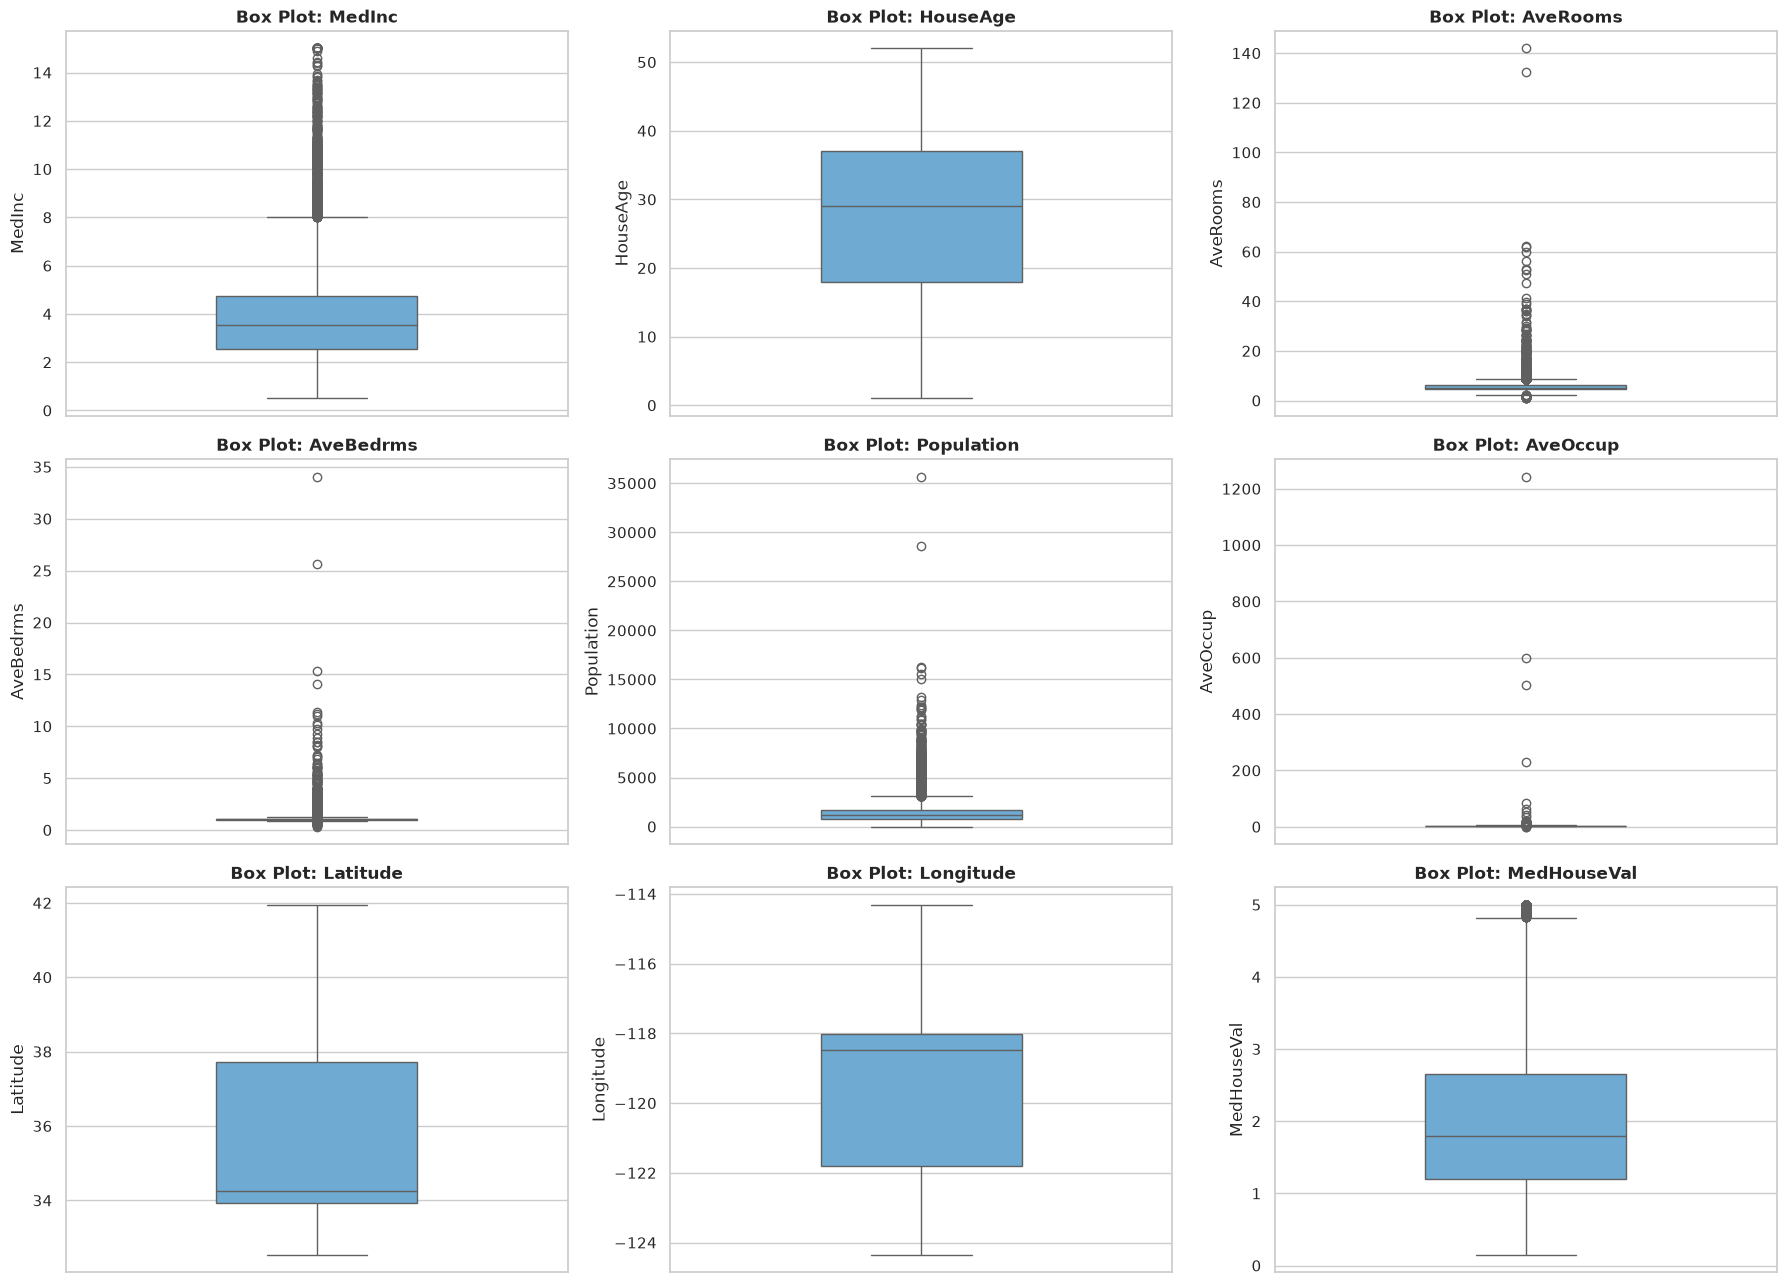

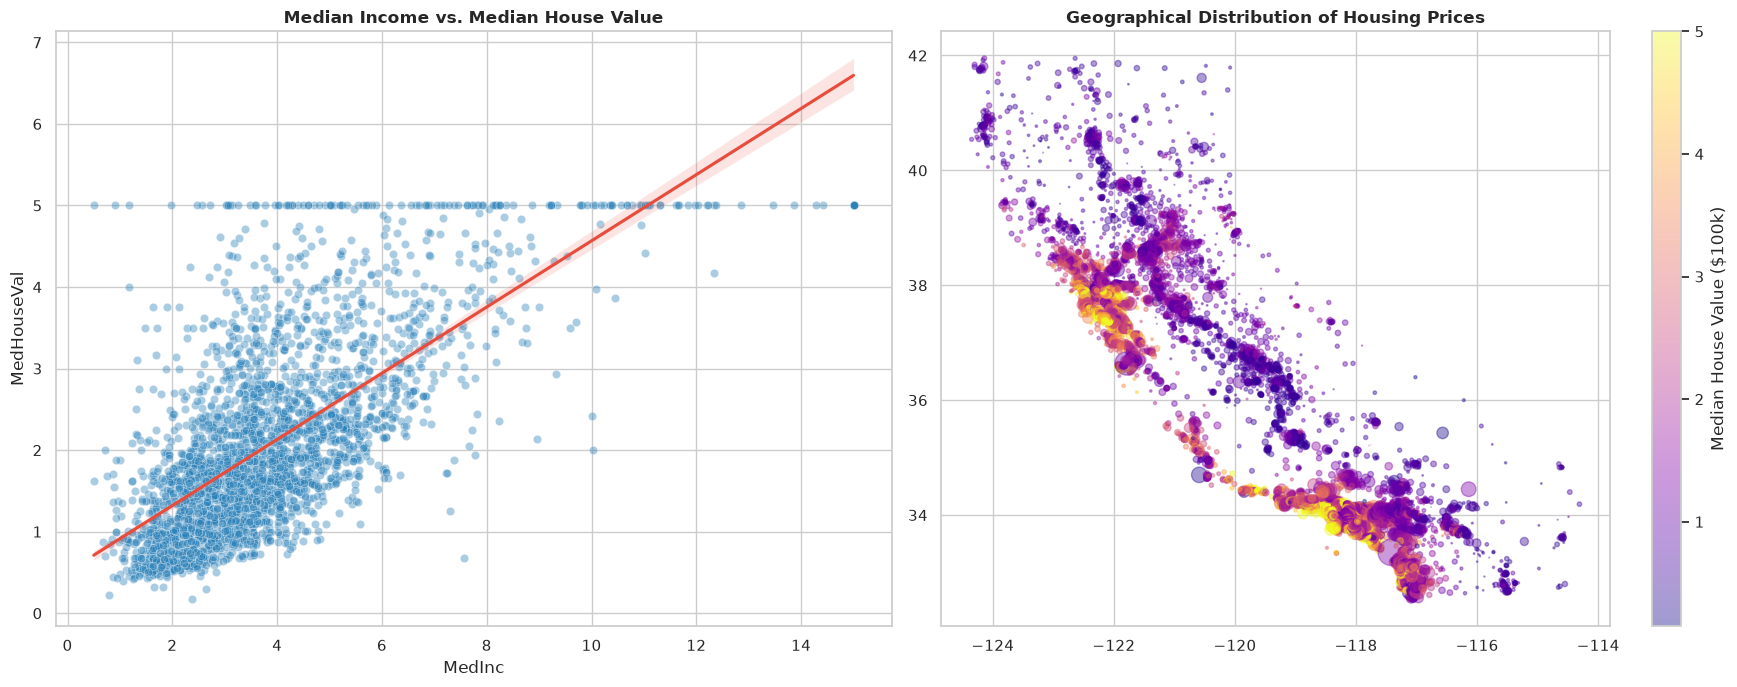

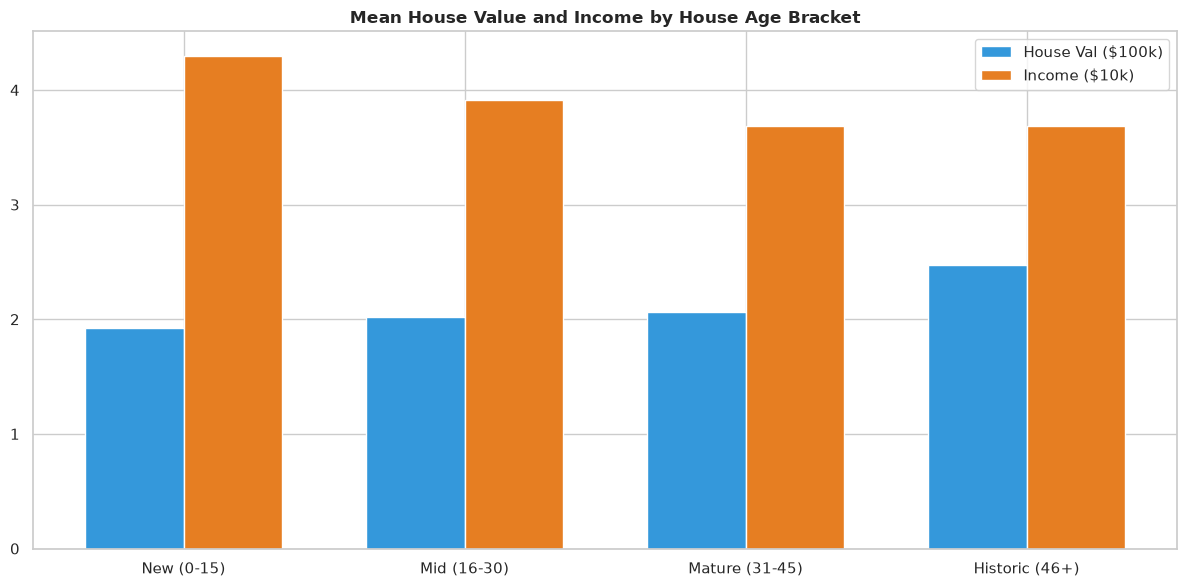

In [25]:
# 1. Histograms for All Features (3x3 Grid)
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    ax = axes[i]
    p99 = df[col].quantile(0.99)
    p01 = df[col].quantile(0.01)
    data_to_plot = df[(df[col] >= p01) & (df[col] <= p99)][col]

    sns.histplot(data_to_plot, kde=True, ax=ax, color="#2b5c8f",
                 bins=30, edgecolor="white")
    ax.axvline(df[col].mean(), color="#e74c3c", ls="--", lw=1.8,
               label=f"Mean: {df[col].mean():.2f}")
    ax.axvline(df[col].median(), color="#27ae60", ls="-.", lw=1.8,
               label=f"Median: {df[col].median():.2f}")
    ax.set_title(f"Distribution of {col}", fontsize=12, weight="bold")
    ax.legend(fontsize=9, loc="upper right")

plt.suptitle("Feature Histograms (Clipped 1st-99th Percentiles)",
             fontsize=16, weight="bold", y=1.00)
plt.tight_layout()
plt.show()

# 2. Box Plots for Outlier & Quartile Visualizations
fig, axes = plt.subplots(3, 3, figsize=(18, 13))
axes = axes.flatten()
for i, col in enumerate(df.columns):
    sns.boxplot(y=df[col], ax=axes[i], color="#5dade2", width=0.4)
    axes[i].set_title(f"Box Plot: {col}", fontsize=12, weight="bold")
plt.tight_layout()
plt.show()

# 3. Scatter Plots (Income vs Price & Geographic Price Mapping)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sample_df = df.sample(3000, random_state=42)
sns.scatterplot(data=sample_df, x="MedInc", y="MedHouseVal",
                alpha=0.4, color="#2980b9", ax=axes[0])
sns.regplot(data=sample_df, x="MedInc", y="MedHouseVal",
            scatter=False, color="#e74c3c", ax=axes[0])
axes[0].set_title("Median Income vs. Median House Value", weight="bold")

scatter = axes[1].scatter(df["Longitude"], df["Latitude"],
                          c=df["MedHouseVal"], cmap="plasma",
                          s=df["Population"]/100, alpha=0.4)
plt.colorbar(scatter, ax=axes[1], label="Median House Value ($100k)")
axes[1].set_title("Geographical Distribution of Housing Prices", weight="bold")
plt.tight_layout()
plt.show()



# 4. Bar Chart: Average House Value & Income by House Age Bracket
df_age = df.copy()
df_age["Age_Bracket"] = pd.cut(
    df["HouseAge"], bins=[0, 15, 30, 45, 60],
    labels=["New (0-15)", "Mid (16-30)", "Mature (31-45)", "Historic (46+)"]
)
age_grp = df_age.groupby("Age_Bracket", observed=True)[["MedHouseVal", "MedInc"]].mean().reset_index()

fig, ax1 = plt.subplots(figsize=(12, 6))
x = np.arange(len(age_grp["Age_Bracket"]))
width = 0.35
ax1.bar(x - width/2, age_grp["MedHouseVal"], width, label="House Val ($100k)", color="#3498db")
ax1.bar(x + width/2, age_grp["MedInc"], width, label="Income ($10k)", color="#e67e22")
ax1.set_xticks(x)
ax1.set_xticklabels(age_grp["Age_Bracket"])
ax1.legend()
plt.title("Mean House Value and Income by House Age Bracket", weight="bold")
plt.tight_layout()
plt.show()

### Visual Findings:
- **Histograms**: `MedInc` has a smooth right-skewed unimodal curve. Coordinates show bimodal density corresponding to Southern (LA) and Northern (Bay Area) population centers.
- **Box Plots**: Significant upper outliers appear in `AveRooms`, `AveBedrms`, `Population`, and `AveOccup`, while spatial features have bounded distributions with no outliers.
- **Spatial Map**: Coastal regions exhibit the highest median house values (bright clusters in SF and LA), while inland valley blocks show substantially lower values.


## 6. Missing Value Injection and Identification


In [26]:
# Introduce ˜5% NaN values randomly into 4 columns (MCAR simulation)
np.random.seed(42)
df_missing = df.copy()
missing_cols = ["MedInc", "HouseAge", "AveRooms", "Population"]
missing_rate = 0.05

for col in missing_cols:
    mask = np.random.rand(len(df_missing)) < missing_rate
    df_missing.loc[mask, col] = np.nan

# Missing Value Summary Table
missing_summary = pd.DataFrame({
    "Feature": df_missing.columns,
    "Missing Count": df_missing.isnull().sum().values,
    "Missing Pct (%)": (df_missing.isnull().mean() * 100).round(2).values
})
print("-- Missing Value Statistics --")
display(missing_summary)

-- Missing Value Statistics --


,Feature,Missing Count,Missing Pct (%)
0,MedInc,1018,4.93
1,HouseAge,1023,4.96
2,AveRooms,1034,5.01
3,AveBedrms,0,0.00
4,Population,1000,4.84
5,AveOccup,0,0.00
6,Latitude,0,0.00
7,Longitude,0,0.00
8,MedHouseVal,0,0.00


## 7. Missing Value Imputation Techniques (Mean vs. KNN)


In [27]:
# Technique 1: Mean Imputation via SimpleImputer
mean_imputer = SimpleImputer(strategy="mean")
df_mean_imputed = pd.DataFrame(
    mean_imputer.fit_transform(df_missing),
    columns=df_missing.columns
)

# Technique 2: KNN Imputation via KNNImputer (k=5)
start_t = time.time()
knn_imputer = KNNImputer(n_neighbors=5)
df_knn_imputed = pd.DataFrame(
    knn_imputer.fit_transform(df_missing),
    columns=df_missing.columns
)
knn_time = time.time() - start_t
print(f"KNN Imputation completed in {knn_time:.2f}s")

# Verification of Null Counts
imputation_check = pd.DataFrame({
    "Feature": df_missing.columns,
    "Original Injected Nulls": df_missing.isnull().sum().values,
    "Mean Imputed Nulls": df_mean_imputed.isnull().sum().values,
    "KNN Imputed Nulls": df_knn_imputed.isnull().sum().values
})
print("\n-- Before vs After Imputation Null Value Audit --")
display(imputation_check)

KNN Imputation completed in 7.58s

-- Before vs After Imputation Null Value Audit --


,Feature,Original Injected Nulls,Mean Imputed Nulls,KNN Imputed Nulls
0,MedInc,1018,0,0
1,HouseAge,1023,0,0
2,AveRooms,1034,0,0
3,AveBedrms,0,0,0
4,Population,1000,0,0
5,AveOccup,0,0,0
6,Latitude,0,0,0
7,Longitude,0,0,0
8,MedHouseVal,0,0,0


## 8. Outlier Detection: IQR Method vs. Z-Score Method


In [28]:
outlier_results = []

for col in df.columns:
    s = df[col]

    # 1. IQR Method
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    iqr_outliers = s[(s < lower_bound) | (s > upper_bound)].count()

    # 2. Z-Score Method (|z| > 3)
    z_scores = np.abs(stats.zscore(s))
    z_outliers = int((z_scores > 3).sum())

    outlier_results.append({
        "Feature": col,
        "IQR Lower Bound": round(lower_bound, 3),
        "IQR Upper Bound": round(upper_bound, 3),
        "IQR Outlier Count": iqr_outliers,
        "IQR Outlier (%)": round(iqr_outliers / len(df) * 100, 2),
        "Z-Score (|z|>3) Count": z_outliers,
        "Z-Score Outlier (%)": round(z_outliers / len(df) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_results).set_index("Feature")
print("-- Outlier Detection Comparison: IQR vs Z-Score (|Z| > 3) --")
display(outlier_df)

-- Outlier Detection Comparison: IQR vs Z-Score (|Z| > 3) --


,IQR Lower Bound,IQR Upper Bound,IQR Outlier Count,IQR Outlier (%),Z-Score (|z|>3) Count,Z-Score Outlier (%)
Feature,,,,,,
MedInc,-0.706,8.013,681,3.30,345,1.67
HouseAge,-10.500,65.500,0,0.00,0,0.00
AveRooms,2.023,8.470,511,2.48,133,0.64
AveBedrms,0.866,1.240,1424,6.90,145,0.70
Population,-620.000,3132.000,1196,5.79,342,1.66
AveOccup,1.151,4.561,711,3.44,8,0.04
Latitude,28.260,43.380,0,0.00,0,0.00
Longitude,-127.485,-112.325,0,0.00,0,0.00
MedHouseVal,-0.981,4.824,1071,5.19,0,0.00


## 9. Outlier Removal Implementation (IQR-Based Trimming)


In [29]:
features_to_filter = ["MedInc", "AveRooms", "AveBedrms", "Population", "AveOccup"]

condition = pd.Series(True, index=df.index)
for col in features_to_filter:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    condition &= (df[col] >= lower) & (df[col] <= upper)

df_cleaned = df[condition].copy()

print("=" * 60)
print(f"Original Dataset Shape : {df.shape} ({df.shape[0]:,} rows)")
print(f"Cleaned Dataset Shape : {df_cleaned.shape} ({df_cleaned.shape[0]:,} rows)")
print(f"Removed Outlier Rows   : {len(df) - len(df_cleaned):,} rows "
      f"({(len(df) - len(df_cleaned)) / len(df) * 100:.2f}%)")
print("=" * 60)

Original Dataset Shape : (20640, 9) (20,640 rows)
Cleaned Dataset Shape : (16842, 9) (16,842 rows)
Removed Outlier Rows   : 3,798 rows (18.40%)


## 10. Feature Normalization Techniques (Min-Max, Standard, Robust)


In [30]:
features = df.columns.tolist()

# 1. Min-Max Scaler [0, 1]
minmax = MinMaxScaler()
df_minmax = pd.DataFrame(minmax.fit_transform(df), columns=features)

# 2. Standard Scaler (Z-Score Normalization)
standard = StandardScaler()
df_standard = pd.DataFrame(standard.fit_transform(df), columns=features)

# 3. Robust Scaler (Median & IQR Based)
robust = RobustScaler()
df_robust = pd.DataFrame(robust.fit_transform(df), columns=features)

def get_norm_stats(data: pd.DataFrame, method_name: str) -> pd.DataFrame:
    rows = []
    for col in data.columns:
        s = data[col]
        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        rows.append({
            "Method": method_name,
            "Feature": col,
            "Mean": s.mean(),
            "Median": s.median(),


            "Std Dev": s.std(),
            "IQR": q3 - q1,
            "Min": s.min(),
            "Max": s.max()
        })
    return pd.DataFrame(rows)

stats_orig = get_norm_stats(df, "Original (Raw)")
stats_minmax = get_norm_stats(df_minmax, "Min-Max Scaler [0, 1]")
stats_std = get_norm_stats(df_standard, "Standard Scaler (Z-Score)")
stats_rob = get_norm_stats(df_robust, "Robust Scaler (IQR-based)")

norm_comparison_df = pd.concat(
    [stats_orig, stats_minmax, stats_std, stats_rob], ignore_index=True
)

selected_cols = ["MedInc", "HouseAge", "Population", "MedHouseVal"]
print("-- Normalization Statistics Comparison across Selected Features --")
display(norm_comparison_df[norm_comparison_df["Feature"].isin(selected_cols)].round(4))

-- Normalization Statistics Comparison across Selected Features --


,Method,Feature,Mean,Median,Std Dev,IQR,Min,Max
0,Original (Raw),MedInc,3.8707,3.5348,1.8998,2.1798,0.4999,15.0001
1,Original (Raw),HouseAge,28.6395,29.0000,12.5856,19.0000,1.0000,52.0000
4,Original (Raw),Population,1425.4767,1166.0000,1132.4621,938.0000,3.0000,35682.0000
8,Original (Raw),MedHouseVal,2.0686,1.7970,1.1540,1.4512,0.1500,5.0000
9,"Min-Max Scaler [0, 1]",MedInc,0.2325,0.2093,0.1310,0.1503,0.0000,1.0000
10,"Min-Max Scaler [0, 1]",HouseAge,0.5420,0.5490,0.2468,0.3725,0.0000,1.0000
13,"Min-Max Scaler [0, 1]",Population,0.0399,0.0326,0.0317,0.0263,0.0000,1.0000
17,"Min-Max Scaler [0, 1]",MedHouseVal,0.3956,0.3396,0.2379,0.2992,0.0000,1.0000
18,Standard Scaler (Z-Score),MedInc,0.0000,-0.1768,1.0000,1.1474,-1.7743,5.8583
19,Standard Scaler (Z-Score),HouseAge,0.0000,0.0286,1.0000,1.5097,-2.1962,1.8562
